Name: Shlok Nikam

Class: CSE-AI (D)

Batch -2

Roll no. 41

PRN: 12414145

Assignment: 8

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

Loading dataset

In [ ]:
df_frame= pd.read_excel("cosmetics_customers_dataset.xlsx")

print("cosmetics Dataset Shape:", df_frame.shape)
print(df_frame.head())


cosmetics Dataset Shape: (1000, 10)
   Customer_ID  Age  Gender  Income Skin_Type  Visits_Per_Month  \
0            1   37  Female  119087       Dry                 9   
1            2   25  Female   96725       Dry                 3   
2            3   32  Female   54671      Oily                11   
3            4   20    Male   62032    Normal                 2   
4            5   45  Female  106813       Dry                12   

   Spent_Last_Month Favorite_Product Membership  Response  
0              6551          Perfume         No         1  
1              5192         Lipstick         No         0  
2              2119          Perfume        Yes         1  
3              1733          Perfume         No         0  
4              1445          Perfume        Yes         1  


converting categorical data into numeric data

In [ ]:
df_frame['Gender']=df_frame['Gender'].map({'Male':0,'Female':1})
df_frame['Membership']=df_frame['Membership'].map({'NO':0,'Yes':1})

In [ ]:
from sklearn.preprocessing import LabelEncoder

df = df_frame.copy()
encoder = LabelEncoder()

for col in ["Gender", "Skin_Type", "Favorite_Product", "Membership"]:
    df[col] = encoder.fit_transform(df[col])


Checking missing values

In [ ]:
print(df.isnull().sum())

Customer_ID         0
Age                 0
Gender              0
Income              0
Skin_Type           0
Visits_Per_Month    0
Spent_Last_Month    0
Favorite_Product    0
Membership          0
Response            0
dtype: int64


Handling missing values

In [ ]:
num_cols = ["Age", "Income", "Visits_Per_Month", "Spent_Last_Month"]
cat_cols = ["Gender", "Skin_Type", "Favorite_Product", "Membership"]

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


Outliers detection

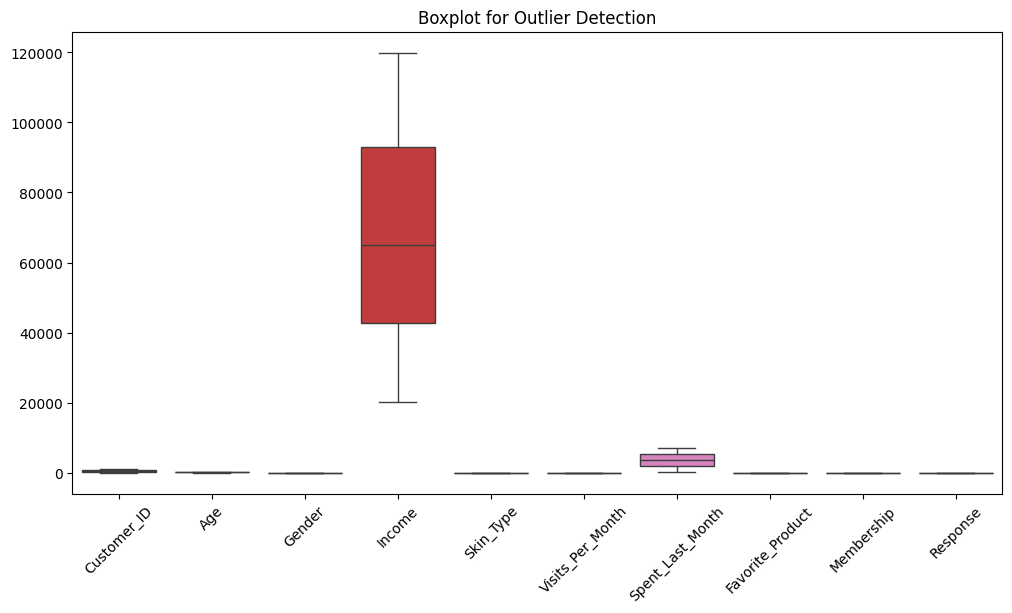

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.show()


Outliers handling

In [ ]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                 (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Before:", df.shape)
print("After:", df_clean.shape)


Before: (1000, 10)
After: (1000, 10)


Finding Correlation

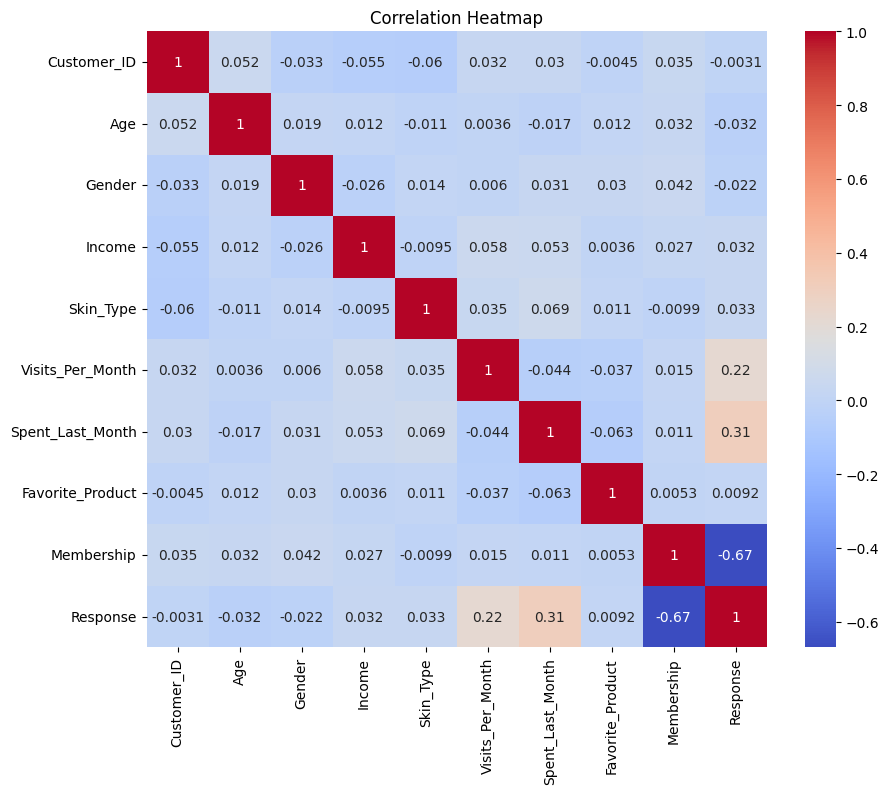

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Model with multiple Independent attributes

In [ ]:
X_1= df[["Income","Visits_Per_Month", "Spent_Last_Month","Skin_Type"]]
y_1 = df["Response"]
scaler_multi = StandardScaler()
X_1_scaled = scaler_multi.fit_transform(X_1)


X_1_train, X_1_test, y_1_train, y_1_test = train_test_split(
    X_1_scaled, y_1, test_size=0.3, random_state=42
)


Feature selecting and model training

In [ ]:
model_1 = LogisticRegression(max_iter=2000)
model_1.fit(X_1_train, y_1_train)


LogisticRegression(max_iter=2000)

In [ ]:
y_1_pred = model_1.predict(X_1_test)
y_1_prob = model_1.predict_proba(X_1_test)[:, 1]


In [ ]:
print("Logistic Regression Results (Multiple Features)")
print("Accuracy :", accuracy_score(y_1_test, y_1_pred))
print("Precision:", precision_score(y_1_test, y_1_pred))
print("Recall   :", recall_score(y_1_test, y_1_pred))
print("F1 Score :", f1_score(y_1_test, y_1_pred))


Logistic Regression Results (Multiple Features)
Accuracy : 0.7133333333333334
Precision: 0.7530364372469636
Recall   : 0.8815165876777251
F1 Score : 0.8122270742358079


ROC Curve

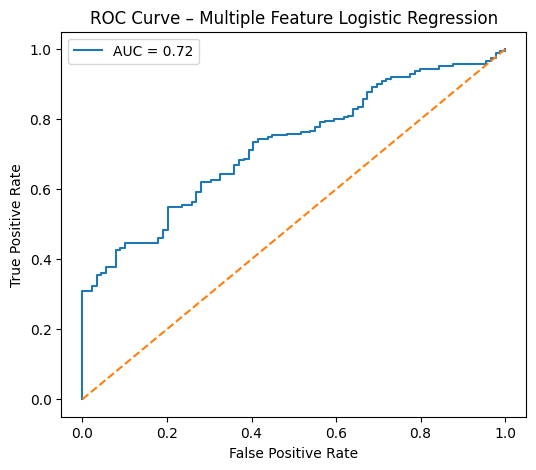

In [ ]:
fpr, tpr, thresholds = roc_curve(y_1_test, y_1_prob)
auc_score = roc_auc_score(y_1_test, y_1_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Multiple Feature Logistic Regression")
plt.legend()
plt.show()


Accuracy

Precision

Recall

F1-score

Confusion Matrix

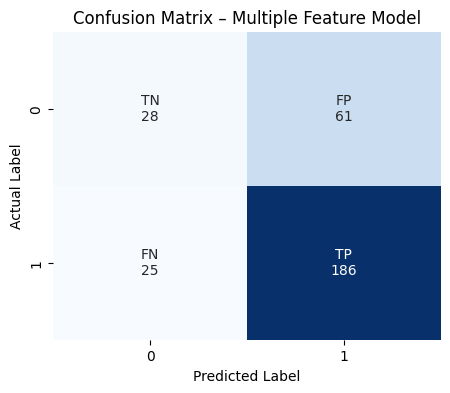

In [ ]:
cm = confusion_matrix(y_1_test, y_1_pred)

TN, FP, FN, TP = cm.ravel()

labels = np.array([
    [f"TN\n{TN}", f"FP\n{FP}"],
    [f"FN\n{FN}", f"TP\n{TP}"]
])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix – Multiple Feature Model")
plt.show()




Model with Only single Attribute

In [ ]:
X_single = df[["Spent_Last_Month"]]
y = df["Response"]

scaler_single = StandardScaler()
X_single_scaled = scaler_single.fit_transform(X_single)

X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    X_single_scaled, y, test_size=0.3, random_state=42
)

model_single = LogisticRegression()
model_single.fit(X_s_train, y_s_train)



LogisticRegression()

In [ ]:
y_s_pred = model_single.predict(X_s_test)
accuracy_single = accuracy_score(y_s_test, y_s_pred)

In [ ]:
print("Logistic Regression Results (Single Feature)")
print("Accuracy:", accuracy_score(y_s_test, y_s_pred))
print("Confusion Matrix:\n", confusion_matrix(y_s_test, y_s_pred))
print("Precision:", precision_score(y_s_test, y_s_pred))
print("Recall:", recall_score(y_s_test, y_s_pred))
print("F1 Score:", f1_score(y_s_test, y_s_pred))


Logistic Regression Results (Single Feature)
Accuracy: 0.7066666666666667
Confusion Matrix:
 [[ 24  65]
 [ 23 188]]
Precision: 0.7430830039525692
Recall: 0.8909952606635071
F1 Score: 0.8103448275862069


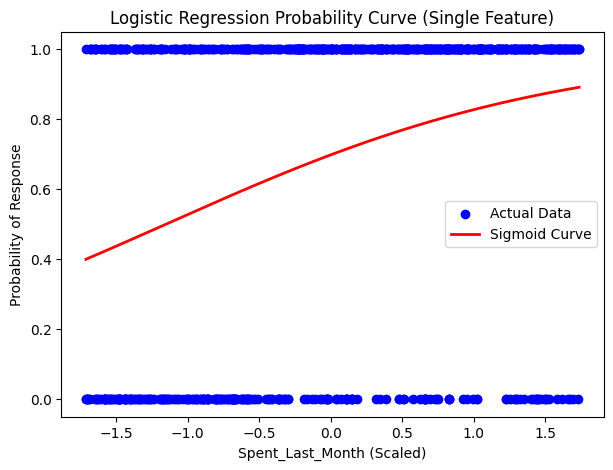

In [ ]:
X_range = np.linspace(
    X_s_train.min(),
    X_s_train.max(),
    300
).reshape(-1, 1)

y_prob_curve = model_single.predict_proba(X_range)[:, 1]

plt.figure(figsize=(7,5))
plt.scatter(X_s_train, y_s_train, color='blue', label='Actual Data')
plt.plot(X_range, y_prob_curve, color='red', linewidth=2, label='Sigmoid Curve')

plt.xlabel("Spent_Last_Month (Scaled)")
plt.ylabel("Probability of Response")
plt.title("Logistic Regression Probability Curve (Single Feature)")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

y_1_pred = model_1.predict(X_1_test)
accuracy_single= accuracy_score(y_s_test, y_s_pred)
accuracy_multi = accuracy_score(y_1_test, y_1_pred)

print("Multiple Feature Accuracy:", accuracy_multi)
print("single feature accuracy", accuracy_single)


Multiple Feature Accuracy: 0.7133333333333334
single feature accuracy 0.7066666666666667


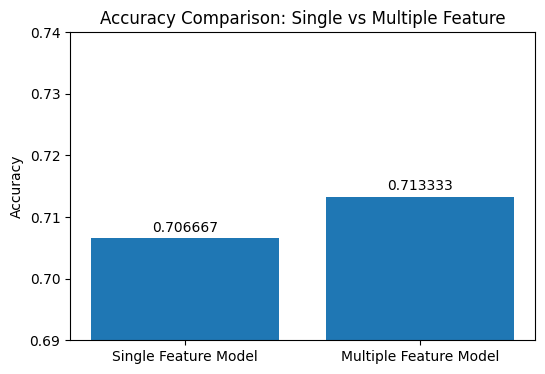

In [ ]:
models = ["Single Feature Model", "Multiple Feature Model"]
accuracies = [accuracy_single, accuracy_multi]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.ylim(0.69, 0.74)
plt.title("Accuracy Comparison: Single vs Multiple Feature")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, f"{v:.6f}", ha='center')

plt.show()



# Using small dataframe

In [ ]:
import pandas as pd

data = pd.DataFrame({
    "Customer_ID": [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17],

    "Age": [37,25,32,20,45,35,32,36,27,29,30,41,39,43,47,50,44],

    "Gender": [
        "Female","Female","Female","Male","Female","Female","Female",
        "Female","Female","Female","Female","Female","Female","Female",
        "Female","Female","Female"
    ],

    "Income": [
        119087,96725,54671,62032,106813,95000,60000,88000,
        72000,76000,80000,110000,99000,115000,120000,130000,125000
    ],

    "Skin_Type": [
        "Dry","Dry","Oily","Normal","Dry","Dry","Normal","Dry","Oily",
        "Dry","Oily","Dry","Normal","Oily","Dry","Oily","Dry"
    ],

    "Visits_Per_Month": [
        9,3,11,2,12,8,6,9,4,5,7,10,8,11,12,13,12
    ],

    "Spent_Last_Month": [
        6551,5192,2119,1733,1445,5800,3200,6000,2800,
        3500,4200,7000,6100,6800,7500,8200,7900
    ],

    "Favorite_Product": [
        "Perfume","Lipstick","Perfume","Perfume","Perfume","Perfume",
        "Cream","Perfume","Lipstick","Cream","Perfume","Perfume",
        "Cream","Perfume","Perfume","Perfume","Perfume"
    ],

    "Membership": [
        "No","No","Yes","No","Yes","Yes","No","Yes","No","No",
        "Yes","Yes","Yes","Yes","Yes","Yes","Yes"
    ],

      "Response": [
        1,0,1,0,1,1,0,1,0,0,1,1,1,1,1,1,1
    ]
})

print(data.head())
print(data.info())


   Customer_ID  Age  Gender  Income Skin_Type  Visits_Per_Month  \
0            1   37  Female  119087       Dry                 9   
1            2   25  Female   96725       Dry                 3   
2            3   32  Female   54671      Oily                11   
3            4   20    Male   62032    Normal                 2   
4            5   45  Female  106813       Dry                12   

   Spent_Last_Month Favorite_Product Membership  Response  
0              6551          Perfume         No         1  
1              5192         Lipstick         No         0  
2              2119          Perfume        Yes         1  
3              1733          Perfume         No         0  
4              1445          Perfume        Yes         1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Customer_ID       17 non-null     int

checking missing values

In [ ]:
print(data.isnull().sum())


Customer_ID         0
Age                 0
Gender              0
Income              0
Skin_Type           0
Visits_Per_Month    0
Spent_Last_Month    0
Favorite_Product    0
Membership          0
Response            0
dtype: int64


Filling Null value

In [ ]:
num_cols = ["Age", "Income", "Visits_Per_Month", "Spent_Last_Month"]
cat_cols = ["Gender", "Skin_Type", "Favorite_Product", "Membership"]

for col in num_cols:
    data[col] = data[col].fillna(data[col].mean())

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])


label encoding for all required columns in dataframe

In [ ]:
df = data.copy()
encoder = LabelEncoder()

for col in ["Gender", "Skin_Type", "Favorite_Product", "Membership"]:
    df[col] = encoder.fit_transform(df[col])


In [ ]:
from sklearn.model_selection import train_test_split
X = df[[ 'Age', 'Income' ,'Spent_Last_Month' ]]
# X = df.drop(["Customer_ID", "Response"], axis=1)
y = df["Response"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


ROC Curve

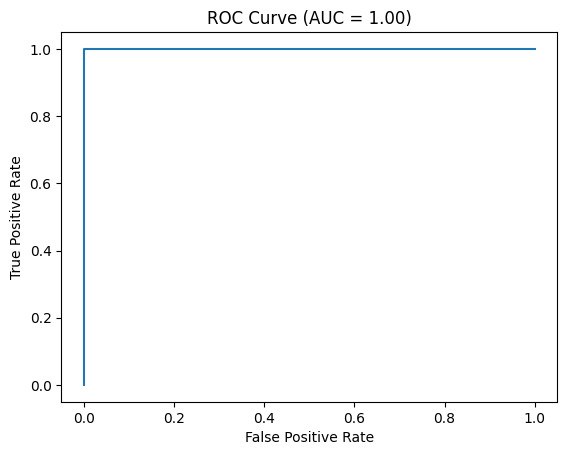

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = %.2f)" % auc_score)
plt.show()


Accuracy

Precision

Recall

F1-score

Confusion Matrix

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


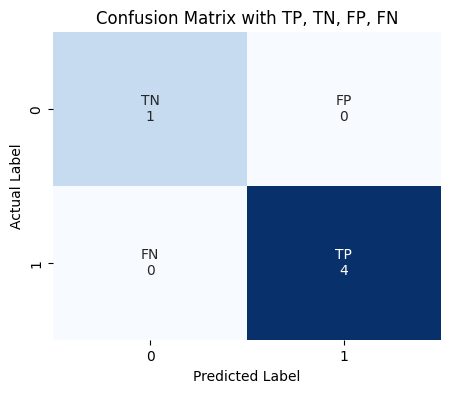

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

labels = np.array([
    [f"TN\n{TN}", f"FP\n{FP}"],
    [f"FN\n{FN}", f"TP\n{TP}"]
])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix with TP, TN, FP, FN")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
plt.show()


#Model with single feature

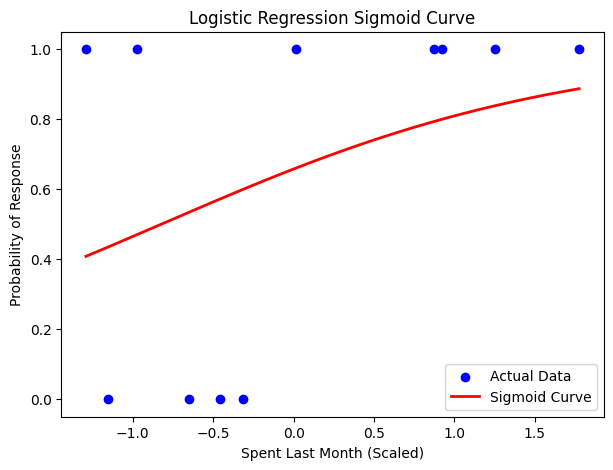

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[["Spent_Last_Month"]]
y = df["Response"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
X_range = np.linspace(
    X_train_scaled.min(),
    X_train_scaled.max(),
    300
).reshape(-1,1)

y_prob_curve = model.predict_proba(X_range)[:,1]

plt.figure(figsize=(7,5))
plt.scatter(X_train_scaled, y_train, color='blue', label='Actual Data')
plt.plot(X_range, y_prob_curve, color='red', linewidth=2, label='Sigmoid Curve')

plt.xlabel("Spent Last Month (Scaled)")
plt.ylabel("Probability of Response")
plt.title("Logistic Regression Sigmoid Curve")
plt.legend()
plt.show()
